In [19]:
from pyomo.environ import *
import pandas as pd
from pathlib import Path

BASE = Path.cwd()

DA_CSV_PATH = BASE /"DA_LMPs_Data/PJM/df_DA_PJM_AECO_2025_DA_hourly.csv"
RT_CSV_PATH = BASE /"RT_LMPs_Data/PJM/df_RT_PJM_AECO_2025_RT_5min.csv"
REG_CSV_PATH = BASE /"reg_zone_prelim_bill_PJM_January_2025.csv"
SIGNALS_CSV_PATH = BASE /"AGC Signal for Regulation/PJM/01_2025_avg_5min_pos_neg.csv"
EV_CSV_PATH = BASE /"EV_fleet_toy.csv"
SCHED_CSV_PATH = BASE /"EV_aggregator_toy_energy&reg_sched_2025_01_15.csv"#

#Time Window used
TZ = "America/New_York"
pt_start = pd.Timestamp("2025-01-15 14:00", tz=TZ)
pt_end   = pd.Timestamp("2025-01-16 14:00", tz=TZ)
# Convert to UTC
utc_start = pt_start.tz_convert("UTC").strftime("%Y-%m-%dT%H:%M:%SZ")
utc_end   = pt_end.tz_convert("UTC").strftime("%Y-%m-%dT%H:%M:%SZ")

#Load Datasets
df_DA_all = pd.read_csv(DA_CSV_PATH)
df_RT_all = pd.read_csv(RT_CSV_PATH)
df_REG_all = pd.read_csv(REG_CSV_PATH)
df_EV = pd.read_csv(EV_CSV_PATH)
df_sched = pd.read_csv(SCHED_CSV_PATH)#

# Clean column names
df_sched.columns = df_sched.columns.astype(str).str.strip()

# Rename the unnamed time/index column safely
for col in df_sched.columns:
    if "unnamed" in col.lower() or col == "":
        df_sched = df_sched.rename(columns={col: "hour"})
        break

print(df_sched.columns)

# Parse the timestamp columns (these files are already UTC with offset)
df_DA_all["interval_start_utc"] = pd.to_datetime(df_DA_all["interval_start_utc"], utc=True)
df_RT_all["interval_start_utc"] = pd.to_datetime(df_RT_all["interval_start_utc"], utc=True)

df_DA = df_DA_all.loc[
    (df_DA_all["interval_start_utc"] >= utc_start) &
    (df_DA_all["interval_start_utc"] <  utc_end)
].sort_values("interval_start_utc").reset_index(drop=True)

df_RT = df_RT_all.loc[
    (df_RT_all["interval_start_utc"] >= utc_start) &
    (df_RT_all["interval_start_utc"] <  utc_end)
].sort_values("interval_start_utc").reset_index(drop=True)

df_REG_all["datetime_beginning_ept"] = pd.to_datetime(df_REG_all["datetime_beginning_ept"])
df_REG_all["datetime_beginning_ept"] = df_REG_all["datetime_beginning_ept"].dt.tz_localize(TZ)

df_REG = df_REG_all.loc[
    (df_REG_all["datetime_beginning_ept"] >= pt_start) &
    (df_REG_all["datetime_beginning_ept"] <  pt_end)
].sort_values("datetime_beginning_ept").reset_index(drop=True)

EV_ids = df_EV["EV"].tolist()

E_bat_max_dict = df_EV.set_index("EV")["E_bat_max (kWh)"].to_dict()
n_dict         = df_EV.set_index("EV")["n"].to_dict()
Pchrg_dict     = df_EV.set_index("EV")["Pchrg (kW)"].to_dict()
SOEa_dict      = df_EV.set_index("EV")["SOEa"].to_dict()
SOEd_dict      = df_EV.set_index("EV")["SOEd"].to_dict()

E_DA = df_sched.set_index("hour")["E_DA_MWh"].to_dict()#
R_DApos = df_sched.set_index("hour")["R_RTpos_MWh"].to_dict()#
R_DAneg = df_sched.set_index("hour")["R_RTneg_MWh"].to_dict()#

Ta_hr = df_EV.set_index("EV")["Ta_hr"].to_dict()
Td_hr = df_EV.set_index("EV")["Td_hr"].to_dict()

T = 24                  # hours
K = 12                  # 5-minute steps per hour
NK = T * K
t0 = 14                 # initial hour of day
k0 = t0 * K             # initial 5-minute interval of day
top = t0+8               #operating hour (14 to 38) each RT problem solves for top = to then top = to+1 etc # 
kop = top * K           #

# --- model time indices (must match model.IDX_t) ---
t_model = list(range(top, t0 + T))        # 15..37
k_start = top * K     # 15*12 = 180 (15:00)
k_end   = k0 + NK - 1            # 455
k_model2 = list(range(k_start, k0 + NK))   # 180..455

# DA hourly prices aligned to absolute hour index
lmp_DA = {t: float(df_DA.loc[t - t0, "lmp"]) for t in t_model}

# RT 5-min prices aligned to absolute 5-min index
lmp_RT = {k: float(df_RT.loc[k - k0, "lmp"]) for k in k_model2}

# Hourly RT averages aligned to absolute hour index
lt_RTE = {}
for t in t_model:
    s = (t - t0) * K
    e = s + K
    lt_RTE[t] = float(df_RT.loc[s:e - 1, "lmp"].mean())

# If your schedule is fixed input (not a decision), align it too:
E_DA_sched   = {t: float(df_sched.set_index("hour").loc[t, "E_DA_MWh"])     for t in t_model}
R_RTpos_sched = {t: float(df_sched.set_index("hour").loc[t, "R_RTpos_MWh"]) for t in t_model}
R_RTneg_sched = {t: float(df_sched.set_index("hour").loc[t, "R_RTneg_MWh"]) for t in t_model}

# Regulation RT clearing price
#lt_RMCCP = {t_keys[i]: float(df_REG.loc[i, "rmccp"]) for i in range(T)} #capacity
#lt_RMPCP = {t_keys[i]: float(df_REG.loc[i, "rmpcp"]) for i in range(T)} #mileage

# RT Signals
RT_Signals = pd.read_csv(SIGNALS_CSV_PATH)
cols = ["1/15/2025_pos", "1/15/2025_neg"]
RT_Signals[cols] = RT_Signals[cols].fillna(0.0)

r_pos_dict = {k: float(RT_Signals.loc[k - k0, "1/15/2025_pos"]) for k in k_model2}
r_neg_dict = {k: float(RT_Signals.loc[k - k0, "1/15/2025_neg"]) for k in k_model2}

def r_dc_pos_init(m, k, w):
    return r_pos_dict[k]

def r_dc_neg_init(m, k, w):
    return -r_neg_dict[k]

def hour_from_k(k):
    return t0 + (k - k0) // K

## Build model
model = ConcreteModel()

## Sets
model.IDX_i = model.IDX_i = Set(initialize=EV_ids)
model.IDX_t = RangeSet(top, t0 + T - 1) #          
model.IDX_k_all = RangeSet(k0, k_end)      # 168..455  (SOE timeline includes k0)
model.IDX_k = RangeSet(k_start, k_end) 
model.IDX_w = Set(initialize=['w1'])             # single scenario

## Parameters
model.Dt     = Param(initialize=1/12)  # 5 minutes in hours
model.prob_w = Param(initialize=1.0)

# LMP Prices
model.l_DAE  = Param(model.IDX_t, initialize=lmp_DA)   # $/MWh
model.lk_RTE = Param(model.IDX_k, initialize=lmp_RT)   # $/MWh
model.lt_RTE = Param(model.IDX_t, initialize=lt_RTE)   # $/MWh

# Regulation Prices
#model.lt_RMCCP = Param(model.IDX_t, initialize=lt_RMCCP)  # capacity price
#model.lt_RMMCP = Param(model.IDX_t, initialize=lt_RMPCP)  # mileage price

#Reg Parameters
model.s_perf = Param(model.IDX_t, initialize = 0.985)
model.a_mil = Param(model.IDX_t, initialize = 1)

# EV fleet parameters
model.E_bat_max = Param(model.IDX_i, initialize=E_bat_max_dict)
model.n         = Param(model.IDX_i, initialize=n_dict)
model.Pchrg     = Param(model.IDX_i, initialize=Pchrg_dict)
model.SOEa      = Param(model.IDX_i, initialize=SOEa_dict)
model.SOEd      = Param(model.IDX_i, initialize=SOEd_dict)
model.SOEcc_cv  = Param(initialize=0.85)

#DA_Schedules
# ---- sanitize DA schedule (avoid tiny negative float noise) ----
sched = df_sched.set_index("hour")

EPS = 1e-6  # MWh tolerance: values in [-EPS, 0) are treated as numerical noise

def clip_nonneg_noise(v, eps=EPS):
    v = float(v)
    if (-eps <= v < 0.0):
        return 0.0
    return v  # keep real negatives as-is (so you notice them)

# build *clipped* schedules for the model horizon
E_DA_sched    = {t: clip_nonneg_noise(sched.loc[t, "E_DA_MWh"])     for t in t_model}
R_RTpos_sched = {t: clip_nonneg_noise(sched.loc[t, "R_RTpos_MWh"])  for t in t_model}
R_RTneg_sched = {t: clip_nonneg_noise(sched.loc[t, "R_RTneg_MWh"])  for t in t_model}

# (optional) hard check: if there are real negatives (below -EPS), raise error
bad_E  = [(t, E_DA_sched[t])    for t in t_model if E_DA_sched[t]    < -EPS]
bad_Rp = [(t, R_RTpos_sched[t]) for t in t_model if R_RTpos_sched[t] < -EPS]
bad_Rn = [(t, R_RTneg_sched[t]) for t in t_model if R_RTneg_sched[t] < -EPS]
if bad_E or bad_Rp or bad_Rn:
    raise ValueError(
        "Found materially negative schedule values (< -EPS). "
        f"E_DA: {bad_E[:5]}  R_RTpos: {bad_Rp[:5]}  R_RTneg: {bad_Rn[:5]}"
    )

# --- now use these clipped dicts when building the Params ---

model.E_DA = Param(model.IDX_t, initialize=E_DA_sched, within=NonNegativeReals)

R_RT_pos_init = {(t, 'w1'): R_RTpos_sched[t] for t in t_model}
R_RT_neg_init = {(t, 'w1'): R_RTneg_sched[t] for t in t_model}

model.R_RT_pos = Param(model.IDX_t, model.IDX_w, initialize=R_RT_pos_init, within=NonNegativeReals)
model.R_RT_neg = Param(model.IDX_t, model.IDX_w, initialize=R_RT_neg_init, within=NonNegativeReals)


# Regulation deployment ratios r 
model.r_pos = Param(model.IDX_k, model.IDX_w, initialize=r_dc_pos_init)
model.r_neg = Param(model.IDX_k, model.IDX_w, initialize= r_dc_neg_init)

# Availability windows (hours counted from 14:00 of the first day;)
Ta_k = {i: int(Ta_hr[i]) * K for i in EV_ids}
Td_k = {i: int(Td_hr[i]) * K for i in EV_ids}

# Convert to absolute sub-steps
#Ta_k = {i: Ta_hr[i] * K for i in Ta_hr}
#Td_k = {i: Td_hr[i] * K for i in Td_hr}

def u_init(model, i, k):
    return 1 if (k >= Ta_k[i] and k < Td_k[i]) else 0

model.u = Param(model.IDX_i, model.IDX_k_all, initialize=u_init, within=Binary)

# DART Spread Penalty settings
dev = 0.3
max_gap = max(0.0, max(lt_RTE[t] - lmp_DA[t] for t in t_model))
M_fixed = 1.01 / (1.0 - dev) * max_gap
model.M = Param(initialize=M_fixed)   # $/MWh

## Decision variables
model.E_RT       = Var(model.IDX_k_all, model.IDX_w, within=NonNegativeReals)                # MWh (agg over EVs)
model.E_i_RT     = Var(model.IDX_i, model.IDX_k_all, model.IDX_w, within=NonNegativeReals)   # kWh
model.SOE        = Var(model.IDX_i, model.IDX_k_all, model.IDX_w, bounds=(0, 1))             # fraction
model.P_RT_max   = Var(model.IDX_i, model.IDX_k_all, model.IDX_w, within=NonNegativeReals)   # kW
model.DEk      = Var(model.IDX_k_all, model.IDX_w)  # signed deviation per 5-min (MWh)
model.DEk_U    = Var(model.IDX_k_all, model.IDX_w)
model.DEk_I    = Var(model.IDX_k_all, model.IDX_w)
model.DEk_U_Up   = Var(model.IDX_k_all, model.IDX_w, within=NonNegativeReals)
model.DEk_U_Down = Var(model.IDX_k_all, model.IDX_w, within=NonNegativeReals)

model.Pnltyk_UUp   = Var(model.IDX_k_all, model.IDX_w, within=NonNegativeReals)
model.Pnltyk_UDown = Var(model.IDX_k_all, model.IDX_w, within=NonNegativeReals)
model.bk           = Var(model.IDX_k_all, model.IDX_w, within=Binary)
#model.R_DA_pos   = Var(model.IDX_t, within=NonNegativeReals)
#model.R_DA_neg   = Var(model.IDX_t, within=NonNegativeReals)
model.E_RT_R_neg = Var(model.IDX_k_all, model.IDX_w, within=NonNegativeReals)
model.E_RT_R_pos = Var(model.IDX_k_all, model.IDX_w, within=NonNegativeReals)

## Constraints
def E_DA_5min_init(m, k):
    t = hour_from_k(k)
    return value(m.E_DA[t]) * value(m.Dt)  # MWh per 5-min
model.E_DA_5min = Param(model.IDX_k, initialize=E_DA_5min_init, within=NonNegativeReals)

def DEk_rule(m, k, w):
    return m.DEk[k, w] == m.E_DA_5min[k] - m.E_RT[k, w]
model.DEk_con = Constraint(model.IDX_k, model.IDX_w, rule=DEk_rule)

model.DEk_split = Constraint(model.IDX_k_all, model.IDX_w, rule=lambda m,k,w: m.DEk[k,w] == m.DEk_U[k,w] + m.DEk_I[k,w])
model.DEk_Usplit = Constraint(model.IDX_k_all, model.IDX_w, rule=lambda m,k,w: m.DEk_U[k,w] == m.DEk_U_Up[k,w] - m.DEk_U_Down[k,w])

def DEkI_rule(m, k, w):
    return m.DEk_I[k, w] == m.E_RT_R_pos[k, w] - m.E_RT_R_neg[k, w]
model.DEkI_con = Constraint(model.IDX_k_all, model.IDX_w, rule=DEkI_rule)

BIGM = 1e6

model.dek_up_limit = Constraint(model.IDX_k_all, model.IDX_w, rule=lambda m,k,w: m.DEk_U_Up[k,w]   <= BIGM * m.bk[k,w])
model.dek_dn_limit = Constraint(model.IDX_k_all, model.IDX_w, rule=lambda m,k,w: m.DEk_U_Down[k,w] <= BIGM * (1 - m.bk[k,w]))
model.dek_pos_enf  = Constraint(model.IDX_k_all, model.IDX_w, rule=lambda m,k,w: m.DEk[k,w] >= -BIGM * (1 - m.bk[k,w]))
model.dek_neg_enf  = Constraint(model.IDX_k_all, model.IDX_w, rule=lambda m,k,w: m.DEk[k,w] <=  BIGM * m.bk[k,w])

# penalty thresholds should also be per 5-min:
def Pk2(m,k,w):
    return m.Pnltyk_UUp[k,w] >= m.M * (m.DEk_U_Up[k,w] - dev * m.E_DA_5min[k])
model.Pk2 = Constraint(model.IDX_k, model.IDX_w, rule=Pk2)

def Pk4(m,k,w):
    return m.Pnltyk_UDown[k,w] >= m.M * (m.DEk_U_Down[k,w] - dev * m.E_DA_5min[k])
model.Pk4 = Constraint(model.IDX_k, model.IDX_w, rule=Pk4)

model.Pk0 = Constraint(model.IDX_k_all, model.IDX_w, rule=lambda m,k,w: m.Pnltyk_UUp[k,w] >= 0)
model.Pk1 = Constraint(model.IDX_k_all, model.IDX_w, rule=lambda m,k,w: m.Pnltyk_UDown[k,w] >= 0)

def r_dcpos_constraint(model, k, w):
    t = hour_from_k(k)
    return model.E_RT_R_pos[k, w] == model.r_pos[k, w] * model.R_RT_pos[t, w]*model.Dt
model.Rdcposcon = Constraint(model.IDX_k, model.IDX_w, rule=r_dcpos_constraint)

def r_dcneg_constraint(model, k, w):
    t = hour_from_k(k)
    return model.E_RT_R_neg[k, w] == model.r_neg[k, w] * model.R_RT_neg[t, w]*model.Dt
model.Rdcnegcon = Constraint(model.IDX_k, model.IDX_w, rule=r_dcneg_constraint)

# Reg-Up capacity (MW): cannot exceed baseline charging within the hour
#def Rpos_constraint(m, t, w):
    #k0_t, k1_t = t * K, (t + 1) * K
    #baseline_MWh = sum(m.E_RT[k, w] for k in range(k0_t, k1_t))
    #return m.R_RT_pos[t, w] <= baseline_MWh
#model.Rposcon = Constraint(model.IDX_t, model.IDX_w, rule=Rpos_constraint)

# Reg-Down capacity (MW): cannot exceed headroom (max possible - baseline)
#def Rneg_constraint(m, t, w):
    #k0_t, k1_t = t * K, (t + 1) * K
    #max_energy_MWh = sum(
        #(m.u[i, k] * m.Pchrg[i] * m.Dt)   # kWh in 5-min
        #for i in m.IDX_i for k in range(k0_t, k1_t)
    #) / 1000.0
    #baseline_MWh = sum(m.E_RT[k, w] for k in range(k0_t, k1_t))
    #return m.R_RT_neg[t, w] <= max_energy_MWh - baseline_MWh
#model.Rnegcon = Constraint(model.IDX_t, model.IDX_w, rule=Rneg_constraint)
#def R3_constraint(model, t, w):
    #return model.R_RT_pos[t, w] <= model.R_DA_pos[t]
#model.R3con = Constraint(model.IDX_t, model.IDX_w, rule=R3_constraint)

model.EVcon = Constraint(
    model.IDX_k_all, model.IDX_w,
    rule=lambda m, k, w: m.E_RT[k, w] == sum(m.E_i_RT[i, k, w] for i in m.IDX_i) / 1000.0
)

model.EV2con = Constraint(
    model.IDX_i, model.IDX_k_all, model.IDX_w,
    rule=lambda m, i, k, w: m.E_i_RT[i, k, w] <= m.P_RT_max[i, k, w] * m.Dt
)

model.EV3con = Constraint(
    model.IDX_i, model.IDX_k_all, model.IDX_w,
    rule=lambda m, i, k, w: m.P_RT_max[i, k, w] <= m.u[i, k] * m.Pchrg[i]
)

def EV4_rule(model, i, k, w):
    return model.P_RT_max[i, k, w] <= model.u[i, k] * model.Pchrg[i] * ((1 - model.SOE[i, k, w]) / (1 - model.SOEcc_cv))
model.EV4con = Constraint(model.IDX_i, model.IDX_k_all, model.IDX_w, rule=EV4_rule)

def SOE_init_k0(model, i, w):
    return model.SOE[i, k0, w] == model.SOEa[i]
model.SOE_init_k0 = Constraint(model.IDX_i, model.IDX_w, rule=SOE_init_k0)

def EV5_rule(model, i, k, w):
    if k == k_end:
        return Constraint.Skip
    return model.SOE[i, k + 1, w] == model.SOE[i, k, w] + (model.n[i] / model.E_bat_max[i]) * model.E_i_RT[i, k, w]
model.EV5con = Constraint(model.IDX_i, model.IDX_k_all, model.IDX_w, rule=EV5_rule)

def EV6_rule(model, i, w):
    k_dep = Td_k[i] - 1
    if k0 <= k_dep < k0 + NK:
        return model.SOE[i, k_dep, w] == model.SOEd[i]
    return Constraint.Skip
model.EV6con = Constraint(model.IDX_i, model.IDX_w, rule=EV6_rule)

## Objective Function
def objFunc_5min(m):
    w = "w1"
    return sum(
        m.lk_RTE[k] * (m.DEk_U[k,w] + m.DEk_I[k,w])
        - m.Pnltyk_UUp[k,w] - m.Pnltyk_UDown[k,w]
        for k in m.IDX_k
    )
model.cost = Objective(rule=objFunc_5min, sense=maximize)

#solve
solver = SolverFactory("gurobi")

#GUROBI options
solver.options["MIPGap"] = 1e-4
solver.options["TimeLimit"] = 300  # seconds

results = solver.solve(model, tee=True)
print(results.solver.status, results.solver.termination_condition)
print(f"Total Profit: ${value(model.cost):.2f}")

# ----------------------------
# 5-min results table (EPT)
# ----------------------------
import numpy as np

w = "w1"

# build 5-min timestamps in America/New_York (EPT/EST/EDT)
k_list = list(model.IDX_k)
t_list = list(model.IDX_t)

# map each k -> timestamp
ts_ept = [pt_start + pd.Timedelta(minutes=5*(k - k0)) for k in k_list]
time_labels = [ts.strftime("%H:%M") for ts in ts_ept]  # "14:00", "14:05", ...

# helper: hour t from k
t_of_k = [hour_from_k(k) for k in k_list]

# 5-min DA "target" energy (if DA schedule is hourly MWh, spread evenly across 12 intervals)
E_DA_5 = [value(model.E_DA[t]) * value(model.Dt) for t in t_of_k]  # MWh per 5-min

out_5min = pd.DataFrame({
    "time_ept": time_labels,
    "k": k_list,
    "t_hour": t_of_k,
    "lmp_RT_$/MWh": [value(model.lk_RTE[k]) for k in k_list],
    "lmp_RT_houravg_$/MWh": [value(model.lt_RTE[t]) for t in t_of_k],
    "E_RT_MWh": [value(model.E_RT[k, w]) for k in k_list],
    "E_DA_hour_MWh": [value(model.E_DA[t]) for t in t_of_k],
    "E_DA_5min_MWh": E_DA_5,
    "E_reg_pos_MWh": [value(model.E_RT_R_pos[k, w]) for k in k_list],
    "E_reg_neg_MWh": [value(model.E_RT_R_neg[k, w]) for k in k_list],
})

# (optional) 5-min net energy including regulation deployment effect
out_5min["E_net_MWh"] = out_5min["E_RT_MWh"] + out_5min["E_reg_pos_MWh"] - out_5min["E_reg_neg_MWh"]

print(out_5min.head(24).round(6))

# Save if you want
#out_5min.to_csv(BASE / "RT_results_5min_2025_01_15_14to38.csv", index=False)

Index(['hour', 'DA_$perMWh', 'RTavg_$perMWh', 'Reg_RMCCP_avg_$perMWh',
       'E_DA_MWh', 'DE_MWh', 'R_RTpos_MWh', 'R_RTneg_MWh'],
      dtype='object')


C:\Users\hsofi\AppData\Local\Temp\ipykernel_32200\1729815931.py:54: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_REG_all["datetime_beginning_ept"] = pd.to_datetime(df_REG_all["datetime_beginning_ept"])


Read LP format model from file C:\Users\hsofi\AppData\Local\Temp\tmp848weae5.pyomo.lp
Reading time = 0.06 seconds
x1: 7299 rows, 5760 columns, 14685 nonzeros
Set parameter MIPGap to value 0.0001
Set parameter TimeLimit to value 300
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11.0 (26100.2))

CPU model: Intel(R) Core(TM) Ultra 7 165U, instruction set [SSE2|AVX|AVX2]
Thread count: 12 physical cores, 14 logical processors, using up to 14 threads

Non-default parameters:
TimeLimit  300

Optimize a model with 7299 rows, 5760 columns and 14685 nonzeros (Max)
Model fingerprint: 0x1f7e90af
Model has 768 linear objective coefficients
Variable types: 5472 continuous, 288 integer (288 binary)
Coefficient statistics:
  Matrix range     [1e-03, 1e+06]
  Objective range  [1e+00, 3e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [2e-05, 1e+06]

Presolve removed 6838 rows and 5279 columns
Presolve time: 0.03s
Presolved: 461 rows, 481 columns, 1555 nonzeros
Variable type

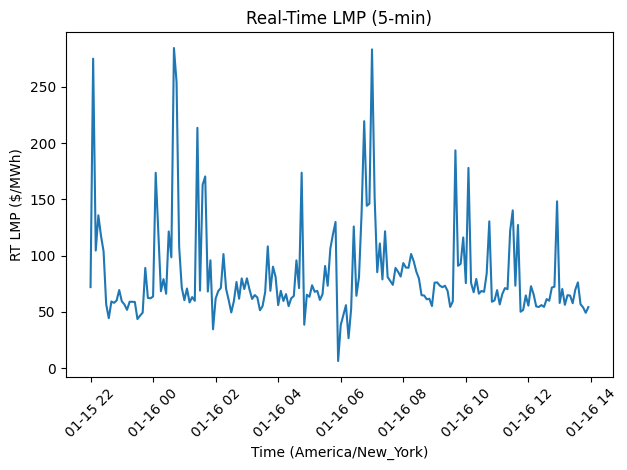

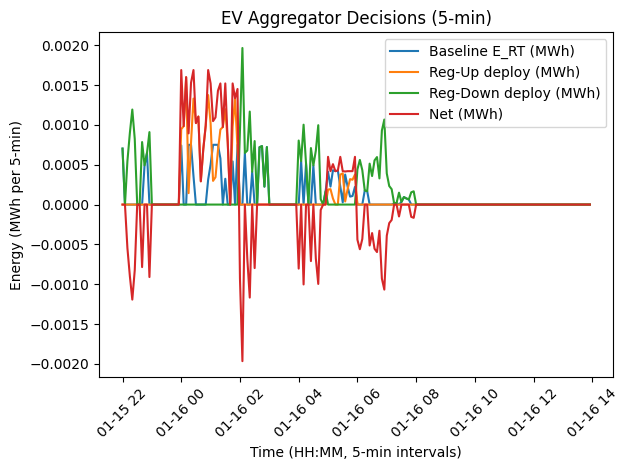

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Build a proper datetime axis (uses your pt_start + k0) ---
# out_5min has k and you already have pt_start, k0 in your script
out_5min = out_5min.copy()

out_5min["datetime_ept"] = [
    pt_start + pd.Timedelta(minutes=5*(k - k0)) for k in out_5min["k"].astype(int).tolist()
]

# --- Plot 1: RT LMP every 5 minutes ---
plt.figure()
plt.plot(out_5min["datetime_ept"], out_5min["lmp_RT_$/MWh"])
plt.xlabel("Time (America/New_York)")
plt.ylabel("RT LMP ($/MWh)")
plt.title("Real-Time LMP (5-min)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Plot 2: Decisions every 5 minutes (baseline + reg + net) ---
plt.figure()
plt.plot(out_5min["datetime_ept"], out_5min["E_RT_MWh"], label="Baseline E_RT (MWh)")
plt.plot(out_5min["datetime_ept"], out_5min["E_reg_pos_MWh"], label="Reg-Up deploy (MWh)")
plt.plot(out_5min["datetime_ept"], out_5min["E_reg_neg_MWh"], label="Reg-Down deploy (MWh)")
plt.plot(out_5min["datetime_ept"], out_5min["E_net_MWh"], label="Net (MWh)")
plt.xlabel("Time (HH:MM, 5-min intervals)")
plt.ylabel("Energy (MWh per 5-min)")
plt.title("EV Aggregator Decisions (5-min)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

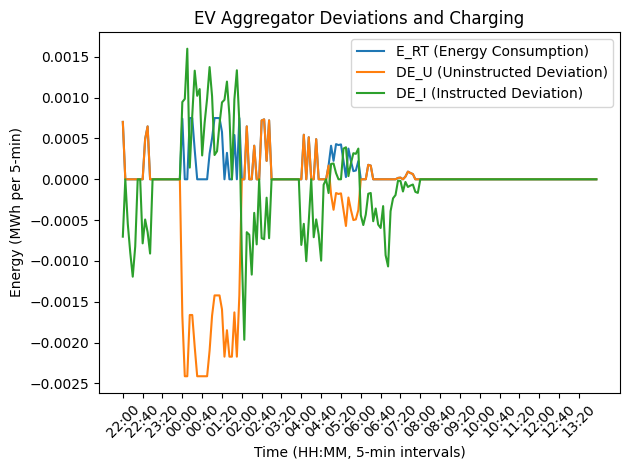

In [11]:
import matplotlib.pyplot as plt

df = out_5min.copy()

# ---- Compute deviations ----
# Instructed deviation = regulation deployment
df["DE_I"] = df["E_reg_pos_MWh"] - df["E_reg_neg_MWh"]

# Total deviation = net − DA target
df["DE_total"] = df["E_net_MWh"] - df["E_DA_5min_MWh"]

# Uninstructed deviation
df["DE_U"] = df["DE_total"] - df["DE_I"]

# ---- Time axis ----
time_labels = df["time_ept"].astype(str)

step = max(len(time_labels)//24, 1)

# ---- Plot ----
plt.figure()

plt.plot(df["E_RT_MWh"], label="E_RT (Energy Consumption)")
plt.plot(df["DE_U"], label="DE_U (Uninstructed Deviation)")
plt.plot(df["DE_I"], label="DE_I (Instructed Deviation)")

plt.xlabel("Time (5-min intervals)")
plt.ylabel("Energy (MWh per 5-min)")
plt.title("EV Aggregator Deviations and Charging")

plt.xticks(
    range(0, len(time_labels), step),
    time_labels.iloc[::step],
    rotation=45
)

plt.legend()
plt.tight_layout()
plt.show()

In [2]:
from pyomo.environ import *
import pandas as pd
from pathlib import Path

BASE = Path.cwd()

DA_CSV_PATH = BASE /"DA_LMPs_Data/PJM/df_DA_PJM_AECO_2025_DA_hourly.csv"
RT_CSV_PATH = BASE /"RT_LMPs_Data/PJM/df_RT_PJM_AECO_2025_RT_5min.csv"
REG_CSV_PATH = BASE /"reg_zone_prelim_bill_PJM_January_2025.csv"
SIGNALS_CSV_PATH = BASE /"AGC Signal for Regulation/PJM/01_2025_avg_5min_pos_neg.csv"
EV_CSV_PATH = BASE /"EV_fleet_toy.csv"
SCHED_CSV_PATH = BASE /"EV_aggregator_toy_energy&reg_sched_2025_01_15.csv"#

#Time Window used
TZ = "America/New_York"
pt_start = pd.Timestamp("2025-01-15 14:00", tz=TZ)
pt_end   = pd.Timestamp("2025-01-16 14:00", tz=TZ)
# Convert to UTC
utc_start = pt_start.tz_convert("UTC").strftime("%Y-%m-%dT%H:%M:%SZ")
utc_end   = pt_end.tz_convert("UTC").strftime("%Y-%m-%dT%H:%M:%SZ")

#Load Datasets
df_DA_all = pd.read_csv(DA_CSV_PATH)
df_RT_all = pd.read_csv(RT_CSV_PATH)
df_REG_all = pd.read_csv(REG_CSV_PATH)
df_EV = pd.read_csv(EV_CSV_PATH)
df_sched = pd.read_csv(SCHED_CSV_PATH)#

# Clean column names
df_sched.columns = df_sched.columns.astype(str).str.strip()

# Rename the unnamed time/index column safely
for col in df_sched.columns:
    if "unnamed" in col.lower() or col == "":
        df_sched = df_sched.rename(columns={col: "hour"})
        break

print(df_sched.columns)

# Parse the timestamp columns (these files are already UTC with offset)
df_DA_all["interval_start_utc"] = pd.to_datetime(df_DA_all["interval_start_utc"], utc=True)
df_RT_all["interval_start_utc"] = pd.to_datetime(df_RT_all["interval_start_utc"], utc=True)

df_DA = df_DA_all.loc[
    (df_DA_all["interval_start_utc"] >= utc_start) &
    (df_DA_all["interval_start_utc"] <  utc_end)
].sort_values("interval_start_utc").reset_index(drop=True)

df_RT = df_RT_all.loc[
    (df_RT_all["interval_start_utc"] >= utc_start) &
    (df_RT_all["interval_start_utc"] <  utc_end)
].sort_values("interval_start_utc").reset_index(drop=True)

df_REG_all["datetime_beginning_ept"] = pd.to_datetime(df_REG_all["datetime_beginning_ept"])
df_REG_all["datetime_beginning_ept"] = df_REG_all["datetime_beginning_ept"].dt.tz_localize(TZ)

df_REG = df_REG_all.loc[
    (df_REG_all["datetime_beginning_ept"] >= pt_start) &
    (df_REG_all["datetime_beginning_ept"] <  pt_end)
].sort_values("datetime_beginning_ept").reset_index(drop=True)

EV_ids = df_EV["EV"].tolist()

E_bat_max_dict = df_EV.set_index("EV")["E_bat_max (kWh)"].to_dict()
n_dict         = df_EV.set_index("EV")["n"].to_dict()
Pchrg_dict     = df_EV.set_index("EV")["Pchrg (kW)"].to_dict()
SOEa_dict      = df_EV.set_index("EV")["SOEa"].to_dict()
SOEd_dict      = df_EV.set_index("EV")["SOEd"].to_dict()

E_DA = df_sched.set_index("hour")["E_DA_MWh"].to_dict()#
R_DApos = df_sched.set_index("hour")["R_RTpos_MWh"].to_dict()#
R_DAneg = df_sched.set_index("hour")["R_RTneg_MWh"].to_dict()#

Ta_hr = df_EV.set_index("EV")["Ta_hr"].to_dict()
Td_hr = df_EV.set_index("EV")["Td_hr"].to_dict()

T = 24                  # hours
K = 12                  # 5-minute steps per hour
NK = T * K
t0 = 14                 # initial hour of day
k0 = t0 * K             # initial 5-minute interval of day
top = t0               #operating hour (14 to 38) each RT problem solves for top = to then top = to+1 etc # 
kop = top * K           #

# --- model time indices (must match model.IDX_t) ---
t_model = list(range(top, t0 + T))        # 15..37
k_start = top * K     # 15*12 = 180 (15:00)
k_end   = k0 + NK - 1            # 455
k_model2 = list(range(k_start, k0 + NK))   # 180..455

# DA hourly prices aligned to absolute hour index
lmp_DA = {t: float(df_DA.loc[t - t0, "lmp"]) for t in t_model}

# RT 5-min prices aligned to absolute 5-min index
lmp_RT = {k: float(df_RT.loc[k - k0, "lmp"]) for k in k_model2}

# Hourly RT averages aligned to absolute hour index
lt_RTE = {}
for t in t_model:
    s = (t - t0) * K
    e = s + K
    lt_RTE[t] = float(df_RT.loc[s:e - 1, "lmp"].mean())

# If your schedule is fixed input (not a decision), align it too:
E_DA_sched   = {t: float(df_sched.set_index("hour").loc[t, "E_DA_MWh"])     for t in t_model}
R_RTpos_sched = {t: float(df_sched.set_index("hour").loc[t, "R_RTpos_MWh"]) for t in t_model}
R_RTneg_sched = {t: float(df_sched.set_index("hour").loc[t, "R_RTneg_MWh"]) for t in t_model}

# Regulation RT clearing price
#lt_RMCCP = {t_keys[i]: float(df_REG.loc[i, "rmccp"]) for i in range(T)} #capacity
#lt_RMPCP = {t_keys[i]: float(df_REG.loc[i, "rmpcp"]) for i in range(T)} #mileage

# RT Signals
RT_Signals = pd.read_csv(SIGNALS_CSV_PATH)
cols = ["1/15/2025_pos", "1/15/2025_neg"]
RT_Signals[cols] = RT_Signals[cols].fillna(0.0)

r_pos_dict = {k: float(RT_Signals.loc[k - k0, "1/15/2025_pos"]) for k in k_model2}
r_neg_dict = {k: float(RT_Signals.loc[k - k0, "1/15/2025_neg"]) for k in k_model2}

def r_dc_pos_init(m, k, w):
    return r_pos_dict[k]

def r_dc_neg_init(m, k, w):
    return -r_neg_dict[k]

def hour_from_k(k):
    return t0 + (k - k0) // K

## Build model
model = ConcreteModel()

## Sets
model.IDX_i = model.IDX_i = Set(initialize=EV_ids)
model.IDX_t = RangeSet(top, t0 + T - 1) #          
model.IDX_k_all = RangeSet(k0, k_end)      # 168..455  (SOE timeline includes k0)
model.IDX_k = RangeSet(k_start, k_end) 
model.IDX_w = Set(initialize=['w1'])             # single scenario

## Parameters
model.Dt     = Param(initialize=1/12)  # 5 minutes in hours
model.prob_w = Param(initialize=1.0)

# LMP Prices
model.l_DAE  = Param(model.IDX_t, initialize=lmp_DA)   # $/MWh
model.lk_RTE = Param(model.IDX_k, initialize=lmp_RT)   # $/MWh
model.lt_RTE = Param(model.IDX_t, initialize=lt_RTE)   # $/MWh

# Regulation Prices
#model.lt_RMCCP = Param(model.IDX_t, initialize=lt_RMCCP)  # capacity price
#model.lt_RMMCP = Param(model.IDX_t, initialize=lt_RMPCP)  # mileage price

#Reg Parameters
model.s_perf = Param(model.IDX_t, initialize = 0.985)
model.a_mil = Param(model.IDX_t, initialize = 1)

# EV fleet parameters
model.E_bat_max = Param(model.IDX_i, initialize=E_bat_max_dict)
model.n         = Param(model.IDX_i, initialize=n_dict)
model.Pchrg     = Param(model.IDX_i, initialize=Pchrg_dict)
model.SOEa      = Param(model.IDX_i, initialize=SOEa_dict)
model.SOEd      = Param(model.IDX_i, initialize=SOEd_dict)
model.SOEcc_cv  = Param(initialize=0.85)

#DA_Schedules
# ---- sanitize DA schedule (avoid tiny negative float noise) ----
sched = df_sched.set_index("hour")

EPS = 1e-6  # MWh tolerance: values in [-EPS, 0) are treated as numerical noise

def clip_nonneg_noise(v, eps=EPS):
    v = float(v)
    if (-eps <= v < 0.0):
        return 0.0
    return v  # keep real negatives as-is (so you notice them)

# build *clipped* schedules for the model horizon
E_DA_sched    = {t: clip_nonneg_noise(sched.loc[t, "E_DA_MWh"])     for t in t_model}
R_RTpos_sched = {t: clip_nonneg_noise(sched.loc[t, "R_RTpos_MWh"])  for t in t_model}
R_RTneg_sched = {t: clip_nonneg_noise(sched.loc[t, "R_RTneg_MWh"])  for t in t_model}

# (optional) hard check: if there are real negatives (below -EPS), raise error
bad_E  = [(t, E_DA_sched[t])    for t in t_model if E_DA_sched[t]    < -EPS]
bad_Rp = [(t, R_RTpos_sched[t]) for t in t_model if R_RTpos_sched[t] < -EPS]
bad_Rn = [(t, R_RTneg_sched[t]) for t in t_model if R_RTneg_sched[t] < -EPS]
if bad_E or bad_Rp or bad_Rn:
    raise ValueError(
        "Found materially negative schedule values (< -EPS). "
        f"E_DA: {bad_E[:5]}  R_RTpos: {bad_Rp[:5]}  R_RTneg: {bad_Rn[:5]}"
    )

# --- now use these clipped dicts when building the Params ---

model.E_DA = Param(model.IDX_t, initialize=E_DA_sched, within=NonNegativeReals)

R_RT_pos_init = {(t, 'w1'): R_RTpos_sched[t] for t in t_model}
R_RT_neg_init = {(t, 'w1'): R_RTneg_sched[t] for t in t_model}

model.R_RT_pos = Param(model.IDX_t, model.IDX_w, initialize=R_RT_pos_init, within=NonNegativeReals)
model.R_RT_neg = Param(model.IDX_t, model.IDX_w, initialize=R_RT_neg_init, within=NonNegativeReals)


# Regulation deployment ratios r 
model.r_pos = Param(model.IDX_k, model.IDX_w, initialize=r_dc_pos_init)
model.r_neg = Param(model.IDX_k, model.IDX_w, initialize= r_dc_neg_init)

# Availability windows (hours counted from 14:00 of the first day;)
Ta_k = {i: int(Ta_hr[i]) * K for i in EV_ids}
Td_k = {i: int(Td_hr[i]) * K for i in EV_ids}

# Convert to absolute sub-steps
#Ta_k = {i: Ta_hr[i] * K for i in Ta_hr}
#Td_k = {i: Td_hr[i] * K for i in Td_hr}

def u_init(model, i, k):
    return 1 if (k >= Ta_k[i] and k < Td_k[i]) else 0

model.u = Param(model.IDX_i, model.IDX_k, initialize=u_init, within=Binary)

# DART Spread Penalty settings
dev = 0.3
max_gap = max(0.0, max(lt_RTE[t] - lmp_DA[t] for t in t_model))
M_fixed = 1.01 / (1.0 - dev) * max_gap
model.M = Param(initialize=M_fixed)   # $/MWh

## Decision variables
model.E_RT       = Var(model.IDX_k, model.IDX_w, within=NonNegativeReals)                # MWh (agg over EVs)
model.E_i_RT     = Var(model.IDX_i, model.IDX_k, model.IDX_w, within=NonNegativeReals)   # kWh
model.SOE        = Var(model.IDX_i, model.IDX_k, model.IDX_w, bounds=(0, 1))             # fraction
model.P_RT_max   = Var(model.IDX_i, model.IDX_k, model.IDX_w, within=NonNegativeReals)   # kW
model.DEk      = Var(model.IDX_k, model.IDX_w)  # signed deviation per 5-min (MWh)
model.DEk_U    = Var(model.IDX_k, model.IDX_w)
model.DEk_I    = Var(model.IDX_k, model.IDX_w)
model.DEk_U_Up   = Var(model.IDX_k, model.IDX_w, within=NonNegativeReals)
model.DEk_U_Down = Var(model.IDX_k, model.IDX_w, within=NonNegativeReals)

model.Pnltyk_UUp   = Var(model.IDX_k, model.IDX_w, within=NonNegativeReals)
model.Pnltyk_UDown = Var(model.IDX_k, model.IDX_w, within=NonNegativeReals)
model.bk           = Var(model.IDX_k, model.IDX_w, within=Binary)
#model.R_DA_pos   = Var(model.IDX_t, within=NonNegativeReals)
#model.R_DA_neg   = Var(model.IDX_t, within=NonNegativeReals)
model.E_RT_R_neg = Var(model.IDX_k, model.IDX_w, within=NonNegativeReals)
model.E_RT_R_pos = Var(model.IDX_k, model.IDX_w, within=NonNegativeReals)

## Constraints
def E_DA_5min_init(m, k):
    t = hour_from_k(k)
    return value(m.E_DA[t]) * value(m.Dt)  # MWh per 5-min
model.E_DA_5min = Param(model.IDX_k, initialize=E_DA_5min_init, within=NonNegativeReals)

def DEk_rule(m, k, w):
    return m.DEk[k, w] == m.E_DA_5min[k] - m.E_RT[k, w]
model.DEk_con = Constraint(model.IDX_k, model.IDX_w, rule=DEk_rule)

model.DEk_split = Constraint(model.IDX_k, model.IDX_w, rule=lambda m,k,w: m.DEk[k,w] == m.DEk_U[k,w] + m.DEk_I[k,w])
model.DEk_Usplit = Constraint(model.IDX_k, model.IDX_w, rule=lambda m,k,w: m.DEk_U[k,w] == m.DEk_U_Up[k,w] - m.DEk_U_Down[k,w])

def DEkI_rule(m, k, w):
    return m.DEk_I[k, w] == m.E_RT_R_pos[k, w] - m.E_RT_R_neg[k, w]
model.DEkI_con = Constraint(model.IDX_k, model.IDX_w, rule=DEkI_rule)

BIGM = 1e6

model.dek_up_limit = Constraint(model.IDX_k, model.IDX_w, rule=lambda m,k,w: m.DEk_U_Up[k,w]   <= BIGM * m.bk[k,w])
model.dek_dn_limit = Constraint(model.IDX_k, model.IDX_w, rule=lambda m,k,w: m.DEk_U_Down[k,w] <= BIGM * (1 - m.bk[k,w]))
model.dek_pos_enf  = Constraint(model.IDX_k, model.IDX_w, rule=lambda m,k,w: m.DEk[k,w] >= -BIGM * (1 - m.bk[k,w]))
model.dek_neg_enf  = Constraint(model.IDX_k, model.IDX_w, rule=lambda m,k,w: m.DEk[k,w] <=  BIGM * m.bk[k,w])

# penalty thresholds should also be per 5-min:
def Pk2(m,k,w):
    return m.Pnltyk_UUp[k,w] >= m.M * (m.DEk_U_Up[k,w] - dev * m.E_DA_5min[k])
model.Pk2 = Constraint(model.IDX_k, model.IDX_w, rule=Pk2)

def Pk4(m,k,w):
    return m.Pnltyk_UDown[k,w] >= m.M * (m.DEk_U_Down[k,w] - dev * m.E_DA_5min[k])
model.Pk4 = Constraint(model.IDX_k, model.IDX_w, rule=Pk4)

model.Pk0 = Constraint(model.IDX_k, model.IDX_w, rule=lambda m,k,w: m.Pnltyk_UUp[k,w] >= 0)
model.Pk1 = Constraint(model.IDX_k, model.IDX_w, rule=lambda m,k,w: m.Pnltyk_UDown[k,w] >= 0)

def r_dcpos_constraint(model, k, w):
    t = hour_from_k(k)
    return model.E_RT_R_pos[k, w] == model.r_pos[k, w] * model.R_RT_pos[t, w]*model.Dt
model.Rdcposcon = Constraint(model.IDX_k, model.IDX_w, rule=r_dcpos_constraint)

def r_dcneg_constraint(model, k, w):
    t = hour_from_k(k)
    return model.E_RT_R_neg[k, w] == model.r_neg[k, w] * model.R_RT_neg[t, w]*model.Dt
model.Rdcnegcon = Constraint(model.IDX_k, model.IDX_w, rule=r_dcneg_constraint)

# Reg-Up capacity (MW): cannot exceed baseline charging within the hour
#def Rpos_constraint(m, t, w):
    #k0_t, k1_t = t * K, (t + 1) * K
    #baseline_MWh = sum(m.E_RT[k, w] for k in range(k0_t, k1_t))
    #return m.R_RT_pos[t, w] <= baseline_MWh
#model.Rposcon = Constraint(model.IDX_t, model.IDX_w, rule=Rpos_constraint)

# Reg-Down capacity (MW): cannot exceed headroom (max possible - baseline)
#def Rneg_constraint(m, t, w):
    #k0_t, k1_t = t * K, (t + 1) * K
    #max_energy_MWh = sum(
        #(m.u[i, k] * m.Pchrg[i] * m.Dt)   # kWh in 5-min
        #for i in m.IDX_i for k in range(k0_t, k1_t)
    #) / 1000.0
    #baseline_MWh = sum(m.E_RT[k, w] for k in range(k0_t, k1_t))
    #return m.R_RT_neg[t, w] <= max_energy_MWh - baseline_MWh
#model.Rnegcon = Constraint(model.IDX_t, model.IDX_w, rule=Rneg_constraint)
#def R3_constraint(model, t, w):
    #return model.R_RT_pos[t, w] <= model.R_DA_pos[t]
#model.R3con = Constraint(model.IDX_t, model.IDX_w, rule=R3_constraint)

model.EVcon = Constraint(
    model.IDX_k, model.IDX_w,
    rule=lambda m, k, w: m.E_RT[k, w] == sum(m.E_i_RT[i, k, w] for i in m.IDX_i) / 1000.0
)

model.EV2con = Constraint(
    model.IDX_i, model.IDX_k, model.IDX_w,
    rule=lambda m, i, k, w: m.E_i_RT[i, k, w] <= m.P_RT_max[i, k, w] * m.Dt
)

model.EV3con = Constraint(
    model.IDX_i, model.IDX_k, model.IDX_w,
    rule=lambda m, i, k, w: m.P_RT_max[i, k, w] <= m.u[i, k] * m.Pchrg[i]
)

def EV4_rule(model, i, k, w):
    return model.P_RT_max[i, k, w] <= model.u[i, k] * model.Pchrg[i] * ((1 - model.SOE[i, k, w]) / (1 - model.SOEcc_cv))
model.EV4con = Constraint(model.IDX_i, model.IDX_k, model.IDX_w, rule=EV4_rule)

def SOE_init_kop(model, i, w):
    return model.SOE[i, kop, w] == model.SOEa[i]
model.SOE_init_kop = Constraint(model.IDX_i, model.IDX_w, rule=SOE_init_kop)

def EV5_rule(model, i, k, w):
    if k == k_end:
        return Constraint.Skip
    return model.SOE[i, k + 1, w] == model.SOE[i, k, w] + (model.n[i] / model.E_bat_max[i]) * model.E_i_RT[i, k, w]
model.EV5con = Constraint(model.IDX_i, model.IDX_k, model.IDX_w, rule=EV5_rule)

def EV6_rule(model, i, w):
    k_dep = Td_k[i] - 1
    if k0 <= k_dep < k0 + NK:
        return model.SOE[i, k_dep, w] == model.SOEd[i]
    return Constraint.Skip
model.EV6con = Constraint(model.IDX_i, model.IDX_w, rule=EV6_rule)

## Objective Function
def objFunc_5min(m):
    w = "w1"
    return sum(
        m.lk_RTE[k] * (m.DEk_U[k,w] + m.DEk_I[k,w])
        - m.Pnltyk_UUp[k,w] - m.Pnltyk_UDown[k,w]
        for k in m.IDX_k
    )
model.cost = Objective(rule=objFunc_5min, sense=maximize)

#solve
solver = SolverFactory("gurobi")

#GUROBI options
solver.options["MIPGap"] = 1e-4
solver.options["TimeLimit"] = 300  # seconds

results = solver.solve(model, tee=True)
print(results.solver.status, results.solver.termination_condition)
print(f"Total Profit: ${value(model.cost):.2f}")

# ----------------------------
# 5-min results table (EPT)
# ----------------------------
import numpy as np

w = "w1"

# build 5-min timestamps in America/New_York (EPT/EST/EDT)
k_list = list(model.IDX_k)
t_list = list(model.IDX_t)

# map each k -> timestamp
ts_ept = [pt_start + pd.Timedelta(minutes=5*(k - k0)) for k in k_list]
time_labels = [ts.strftime("%H:%M") for ts in ts_ept]  # "14:00", "14:05", ...

# helper: hour t from k
t_of_k = [hour_from_k(k) for k in k_list]

# 5-min DA "target" energy (if DA schedule is hourly MWh, spread evenly across 12 intervals)
E_DA_5 = [value(model.E_DA[t]) * value(model.Dt) for t in t_of_k]  # MWh per 5-min

out_5min = pd.DataFrame({
    "time_ept": time_labels,
    "k": k_list,
    "t_hour": t_of_k,
    "lmp_RT_$/MWh": [value(model.lk_RTE[k]) for k in k_list],
    "lmp_RT_houravg_$/MWh": [value(model.lt_RTE[t]) for t in t_of_k],
    "E_RT_MWh": [value(model.E_RT[k, w]) for k in k_list],
    "E_DA_hour_MWh": [value(model.E_DA[t]) for t in t_of_k],
    "E_DA_5min_MWh": E_DA_5,
    "E_reg_pos_MWh": [value(model.E_RT_R_pos[k, w]) for k in k_list],
    "E_reg_neg_MWh": [value(model.E_RT_R_neg[k, w]) for k in k_list],
})

# (optional) 5-min net energy including regulation deployment effect
out_5min["E_net_MWh"] = out_5min["E_RT_MWh"] + out_5min["E_reg_pos_MWh"] - out_5min["E_reg_neg_MWh"]

print(out_5min.head(24).round(6))

# Save if you want
#out_5min.to_csv(BASE / "RT_results_5min_2025_01_15_14to38.csv", index=False)

Index(['hour', 'DA_$perMWh', 'RTavg_$perMWh', 'Reg_RMCCP_avg_$perMWh',
       'E_DA_MWh', 'DE_MWh', 'R_RTpos_MWh', 'R_RTneg_MWh'],
      dtype='object')


C:\Users\hsofi\AppData\Local\Temp\ipykernel_34552\714524216.py:54: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_REG_all["datetime_beginning_ept"] = pd.to_datetime(df_REG_all["datetime_beginning_ept"])


Read LP format model from file C:\Users\hsofi\AppData\Local\Temp\tmplk2mvg_2.pyomo.lp
Reading time = 0.06 seconds
x1: 7779 rows, 5760 columns, 15453 nonzeros
Set parameter MIPGap to value 0.0001
Set parameter TimeLimit to value 300
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) Ultra 7 165U, instruction set [SSE2|AVX|AVX2]
Thread count: 12 physical cores, 14 logical processors, using up to 14 threads

Non-default parameters:
TimeLimit  300

Optimize a model with 7779 rows, 5760 columns and 15453 nonzeros (Max)
Model fingerprint: 0x1dae3ed9
Model has 1152 linear objective coefficients
Variable types: 5472 continuous, 288 integer (288 binary)
Coefficient statistics:
  Matrix range     [1e-03, 1e+06]
  Objective range  [1e+00, 3e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [2e-05, 1e+06]

Presolve removed 7318 rows and 5148 columns
Presolve time: 0.05s
Presolved: 461 rows, 612 columns, 1708 nonzeros
Variable ty